In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, root_mean_squared_error

In [3]:
df = pd.read_csv('car_listings.csv')
df.head()

,brand,city,model_year,age_years,mileage_km,engine_cc,condition_score,price
0,KIA,Sahiwal,2024,2,25080,1800,10.00,3692858
1,Hyundai,Lahore,2011,15,122955,1300,3.62,1611610
2,Honda,Faisalabad,2019,7,88222,1500,4.82,2654250
3,Hyundai,Lahore,2016,10,99549,1800,4.12,1758053
4,Hyundai,Sahiwal,2019,7,54977,1500,7.27,2370113


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            600 non-null    str    
 1   city             600 non-null    str    
 2   model_year       600 non-null    int64  
 3   age_years        600 non-null    int64  
 4   mileage_km       600 non-null    int64  
 5   engine_cc        600 non-null    int64  
 6   condition_score  600 non-null    float64
 7   price            600 non-null    int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 45.3 KB


In [5]:
df.describe()

,model_year,age_years,mileage_km,engine_cc,condition_score,price
count,600.000000,600.000000,600.000000,600.000000,600.000000,6.000000e+02
mean,2015.750000,10.250000,122327.996667,1426.133333,3.872883,1.708121e+06
std,4.951265,4.951265,64878.093168,313.062927,2.773056,1.023452e+06
min,2008.000000,2.000000,13424.000000,660.000000,1.000000,2.500000e+05
25%,2012.000000,6.000000,63978.250000,1300.000000,1.000000,8.756330e+05
50%,2015.000000,11.000000,121047.000000,1500.000000,3.215000,1.680866e+06
75%,2020.000000,14.000000,168207.250000,1800.000000,6.227500,2.371560e+06
max,2024.000000,18.000000,295916.000000,1800.000000,10.000000,4.062035e+06


In [6]:
df.isnull().sum()

brand              0
city               0
model_year         0
age_years          0
mileage_km         0
engine_cc          0
condition_score    0
price              0
dtype: int64

In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

df[df.duplicated()]

Number of duplicate rows: 0


,brand,city,model_year,age_years,mileage_km,engine_cc,condition_score,price


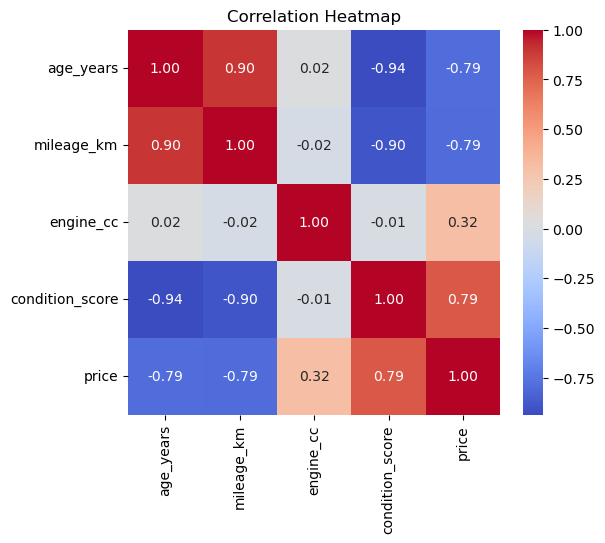

In [8]:
corr = df[['age_years', 'mileage_km', 'engine_cc', 'condition_score', 'price']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
X = df.drop(columns=['price', 'model_year'])
y = df['price']

numeric_features = ['age_years', 'mileage_km', 'engine_cc', 'condition_score']
categorical_features = ['brand', 'city']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(X_train.shape, X_test.shape)

(480, 6) (120, 6)


In [14]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])

lr_pipe.fit(X_train, y_train)

y_pred_train_lr = lr_pipe.predict(X_train)
y_pred_test_lr = lr_pipe.predict(X_test)

print('Linear Train R2:', round(r2_score(y_train, y_pred_train_lr), 4))
print('Linear Test R2:', round(r2_score(y_test, y_pred_test_lr), 4))

print('Linear Train RMSE:', round(root_mean_squared_error(y_train, y_pred_train_lr), 0))
print('Linear Test RMSE:', round(root_mean_squared_error(y_test, y_pred_test_lr), 0))

Linear Train R2: 0.9615
Linear Test R2: 0.9619
Linear Train RMSE: 202092.0
Linear Test RMSE: 193316.0


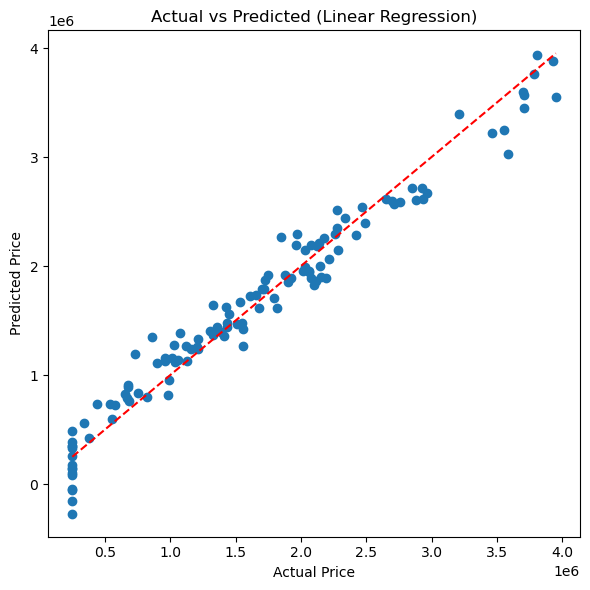

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted (Linear Regression)')
plt.tight_layout()
plt.show()

In [17]:
import joblib
joblib.dump(lr_pipe, 'ridge_car_price_model.pkl')

['ridge_car_price_model.pkl']